<a href="https://colab.research.google.com/github/ngohoangkha1508-hue/THDeeplearning/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lỗi tải dữ liệu: URL can't contain control characters. '/thanh dungle/Data-Science/main/processed_dulieuxettuyendaihoc.csv' (found at least ' ')
Đang tạo dữ liệu mẫu để demo...

=== PHẦN 1: THỐNG KÊ DỮ LIỆU ===

1. Top 5 DH1 tăng dần:
   GT       DH1
4  M  3.482348
5  M  3.948864
1  F  4.007223
2  M  4.463139
8  M  5.546862

3. Thống kê điểm DH1 theo khối thi (KT):
     Count        Sum      Mean    Median       Min       Max       Std  \
KT                                                                       
A       5  31.120946  6.224189  6.660526  3.482348  7.808093  1.628631   
A1      2  10.771036  5.385518  5.385518  4.007223  6.763813  1.949204   
B       3  13.958865  4.652955  4.463139  3.948864  5.546862  0.815734   

          Q1        Q2        Q3  
KT                                
A   6.327534  6.660526  6.842445  
A1  4.696370  5.385518  6.074666  
B   4.206001  4.463139  5.005001  

=== PHẦN 2: TRỰC QUAN HÓA BIẾN GT ===


/tmp/ipykernel_8344/69518694.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tan_so_gt.index, y=tan_so_gt.values, ax=axes[0], palette='Set2')


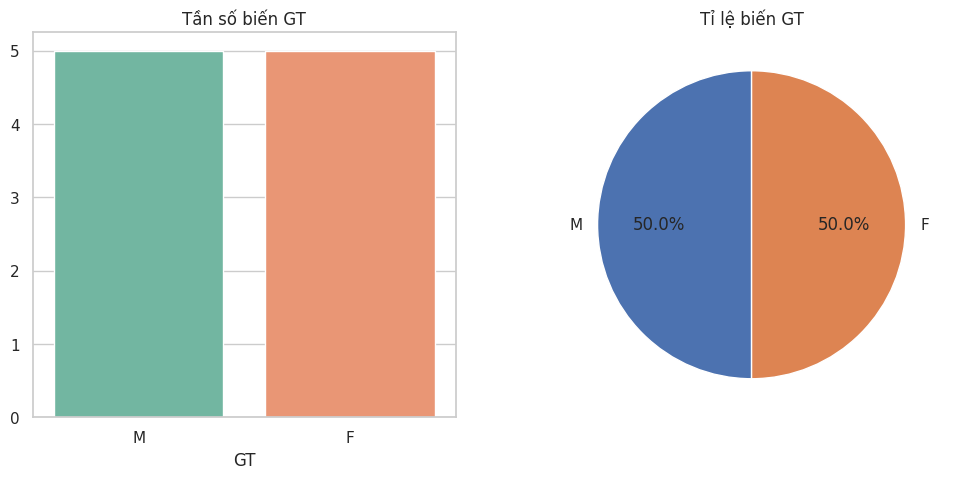


=== PHẦN 4 & 5: PHÂN LỚP VÀ PHÂN PHỐI ===


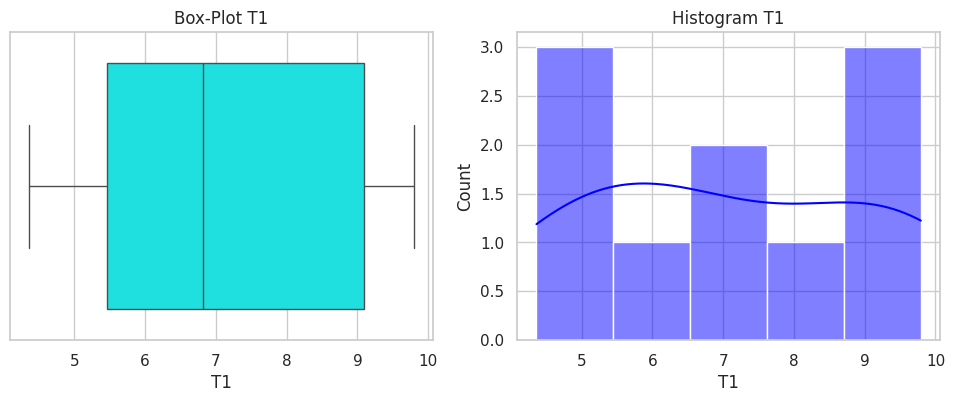

Hệ số tương quan giữa DH1 và T1: 0.2392


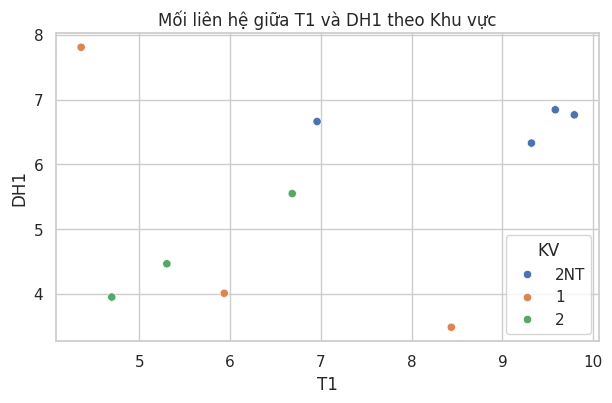


=== HOÀN THÀNH LAB 02 ===


In [ ]:
# ==============================================================================
# BÀI THỰC HÀNH TRÌNH BÀY DỮ LIỆU (LAB 02)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ------------------------------------------------------------------------------
# 0. CHUẨN BỊ THƯ VIỆN VÀ DATASET
# ------------------------------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cập nhật URL mới (Đảm bảo file tồn tại)
url = "https://raw.githubusercontent.com/thanh dungle/Data-Science/main/processed_dulieuxettuyendaihoc.csv"

try:
    df = pd.read_csv(url)
    print("--- TẢI DỮ LIỆU THÀNH CÔNG ---")
    print(df.head())
except Exception as e:
    print(f"Lỗi tải dữ liệu: {e}")
    # Tạo dữ liệu giả lập nếu URL vẫn lỗi để bạn có thể test code
    print("Đang tạo dữ liệu mẫu để demo...")
    data = {
        'STT': range(1, 11),
        'GT': ['M', 'F', 'M', 'F', 'M', 'M', 'F', 'F', 'M', 'F'],
        'DT': ['Kinh', 'Kinh', '1', 'Kinh', 'Kinh', '2', 'Kinh', 'Kinh', 'Kinh', 'Kinh'],
        'KV': ['2NT', '1', '2', '2NT', '1', '2', '2NT', '1', '2', '2NT'],
        'DH1': np.random.uniform(2, 9, 10),
        'DH2': np.random.uniform(2, 9, 10),
        'DH3': np.random.uniform(2, 9, 10),
        'T1': np.random.uniform(4, 10, 10),
        'KT': ['A', 'A1', 'B', 'A', 'A', 'B', 'A1', 'A', 'B', 'A'],
        'KQXT': [1, 0, 1, 1, 0, 0, 1, 0, 1, 1],
        'TBM1': np.random.uniform(5, 9, 10),
        'TBM2': np.random.uniform(5, 9, 10),
        'TBM3': np.random.uniform(5, 9, 10)
    }
    df = pd.DataFrame(data)

# ------------------------------------------------------------------------------
# PHẦN 1: THỐNG KÊ DỮ LIỆU
# ------------------------------------------------------------------------------
print("\n=== PHẦN 1: THỐNG KÊ DỮ LIỆU ===")

# 1. Sắp xếp DH1 tăng dần
df_sorted_dh1 = df.sort_values(by='DH1', ascending=True)
print("\n1. Top 5 DH1 tăng dần:\n", df_sorted_dh1[['GT', 'DH1']].head())

# 3. Pivot-table (Tứ phân vị)
def q1(x): return x.quantile(0.25)
def q2(x): return x.quantile(0.50)
def q3(x): return x.quantile(0.75)

columns_mapping = ['Count', 'Sum', 'Mean', 'Median', 'Min', 'Max', 'Std', 'Q1', 'Q2', 'Q3']
pivot_kt = df.pivot_table(values='DH1', index='KT', aggfunc=['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3])
pivot_kt.columns = columns_mapping
print("\n3. Thống kê điểm DH1 theo khối thi (KT):\n", pivot_kt)

# ------------------------------------------------------------------------------
# PHẦN 2: TRÌNH BÀY DỮ LIỆU (TRỰC QUAN BIẾN GT)
# ------------------------------------------------------------------------------
print("\n=== PHẦN 2: TRỰC QUAN HÓA BIẾN GT ===")
tan_so_gt = df['GT'].value_counts()
tan_suat_gt = df['GT'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=tan_so_gt.index, y=tan_so_gt.values, ax=axes[0], palette='Set2')
axes[0].set_title('Tần số biến GT')

axes[1].pie(tan_suat_gt, labels=tan_suat_gt.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỉ lệ biến GT')
plt.show()

# ------------------------------------------------------------------------------
# PHẦN 4 & 5: PHÂN LỚP VÀ TƯƠNG QUAN
# ------------------------------------------------------------------------------
print("\n=== PHẦN 4 & 5: PHÂN LỚP VÀ PHÂN PHỐI ===")

# Phân lớp điểm Toán T1
bins = [0.0, 5.0, 7.0, 8.0, 10.1] # 10.1 để bao gồm cả điểm 10
labels = ['k', 'tb', 'kh', 'g']
df['phanlopt1'] = pd.cut(df['T1'], bins=bins, labels=labels, right=False)

# Biểu đồ Boxplot và Histogram cho T1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['T1'], ax=axes[0], color='cyan')
axes[0].set_title('Box-Plot T1')

sns.histplot(df['T1'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Histogram T1')
plt.show()

# Tương quan DH1 và T1
corr_val = df['DH1'].corr(df['T1'])
print(f"Hệ số tương quan giữa DH1 và T1: {corr_val:.4f}")

plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='T1', y='DH1', hue='KV', palette='deep')
plt.title('Mối liên hệ giữa T1 và DH1 theo Khu vực')
plt.show()

print("\n=== HOÀN THÀNH LAB 02 ===")